# Simulating a regime-switching diffusion process


<div class="note"><span class="note-t">In brief</span>
<p>We let a discrete regime cycle on a pdit, Torx's d-state site, and use its state to choose the Gaussian law for the next position increment. This gives a regime-switching diffusion sampler whose only jumps are the latent regime switches; because each part of one step has a closed form, we can compare the regime-conditioned laws, stationary occupancy, and terminal mean with analytic references.</p>
</div>

A **[regime-switching (Markov-modulated) diffusion](#ref-yin-zhu-2010)** couples continuous motion to a hidden discrete state. In the model we build here, the latent regime $S_t$ selects the drift and diffusion of the position $X_t$, while only $S_t$ jumps. Thus, $X_t$ is a latent-jump controlled diffusion rather than a jump-diffusion with discontinuities in $X$ itself.

<details class="tx-disclosure"><summary>Term: Torx sites and time stepping</summary><p>A pdit is a Torx discrete-valued site, while a pmode is a continuous-valued site. A generator gives the infinitesimal rule, and an <a href="#ref-kloeden-platen-1992">Euler step</a> with a <a href="#ref-trotter-1959">Lie-Trotter split</a> approximates it by applying small regime and position updates in sequence.</p></details>

This description suggests two separate updates: advance the discrete Markov chain, then draw a Gaussian increment whose parameters depend on the resulting regime. We implement them with `PditCycle` and `MixtureGaussianGate`. Torx also provides the binary-firing `torx.psc.JumpDiffusionGate`, but that gate introduces jumps in $X$ itself and therefore represents a different model.

The same pattern appears in regime-switching finance, neural spike trains, and other systems where an unobserved state changes the local drift or noise level of a continuous signal. Once we condition on the regime, the Gaussian gate produces a Gaussian step; after we marginalize the regime, the transition law is generally a non-Gaussian mixture.

We will construct and check the sampler in three stages:

1. advance a 3-state regime with `PditCycle`, then apply a regime-conditioned Gaussian increment with `MixtureGaussianGate`,
2. compose the gates into one Euler step with `HybridPCircuit` and scan that step into joint discrete and continuous sample paths, and
3. compare the one-step mixture law and occupancy with their references, then compare the terminal mean with an exact reference for the discretized Torx chain.

The continuous update uses the same `MixtureGaussianGate` primitive as [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb). For comparison, [`12_langevin_graph_ising.ipynb`](12_langevin_graph_ising.ipynb) constructs a custom nonlinear Langevin gate on the same continuous `pmode` site.

## Setup

The setup cells import Torx, JAX, SciPy, and the plotting helpers, then apply the shared notebook style, so the process itself doesn't enter until the next section.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>Torx: <code>PditCycle</code>, <code>MixtureGaussianGate</code>, <code>HybridPCircuit</code>, and <code>HybridSampleSimulator</code> execute each sampled step.</li><li>Notebook code: <code>scan</code> advances time and <code>vmap</code> batches paths.</li><li>Helpers: <code>examples/helpers/_affine_gaussian.py</code> supplies reference densities, while <code>examples/helpers/_notebook_paths.py</code>, <code>examples/helpers/_notebook_style.py</code>, <code>examples/helpers/_plots_fields.py</code>, and <code>examples/helpers/_plots_schematics.py</code> handle paths, style, and figures.</li></ul></details>

In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np
from scipy import stats
from scipy.linalg import expm



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)
import _plots_fields as P_fld
import _plots_schematics as P_sch



In [4]:
from _affine_gaussian import mixture_density
from torx.psc import (
    HybridPCircuit,
    MixtureGaussianGate,
    PditCycle,
)



In [5]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)
SEED = 123

## The process and its gates

We begin with the process we want to sample, since its two terms determine the Torx gates directly. The position $X_t$ follows a regime-switching stochastic differential equation (SDE): both its drift and volatility are selected by a latent regime $S_t$, which evolves as a continuous-time Markov chain.

$$
dX_t = \underbrace{\mu_{S_t}\,dt}_{\vphantom{\big|}\text{drift}} + \underbrace{\sigma_{S_t}\,dW_t}_{\vphantom{\big|}\text{diffusion}}.
$$

Here $W_t$ is a standard Wiener (Brownian) process. Conditioning on $S_t$ selects one pair $(\mu, \sigma)$ and therefore one local Gaussian law for the continuous increment.

To simulate the process on a grid with step $\Delta t$, we first need a discrete approximation to the regime chain. `PditCycle` supplies its $O(\Delta t)$ [Euler discretization](#ref-kloeden-platen-1992), with switching probabilities that are linear in $\Delta t$.

The discrete state changes the continuous transition kernel. Conditioned on a regime, the increment is Gaussian; if the regime is unobserved and marginalized out, the same increment follows a mixture of Gaussians.

We must also choose how to interleave the discrete and continuous updates. The infinitesimal generator splits into a regime part and a position part, $A = A_S + A_X$, and these operators do not commute. We therefore approximate their joint evolution by applying the regime update first and the position update second. This [Lie-Trotter split](#ref-trotter-1959) has local one-step error $O(\Delta t^2)$ and first-order global error $O(\Delta t)$ over the full interval.

$$
T_{\text{Trotter}}(\Delta t) = \underbrace{T_{\text{MoG}}(\Delta t)}_{\vphantom{\big|}\text{position step}}\, \underbrace{T_{\text{PditCycle}}(\Delta t)}_{\vphantom{\big|}\text{regime switch}}.
$$

Operator products act from right to left, so `PditCycle` advances the regime before the Gaussian update is applied. For the cyclic 3-state chain, one step of size $\Delta t$:

- moves forward with probability $p_+ = \lambda_+\Delta t$,
- moves backward with probability $p_- = \lambda_-\Delta t$, and
- stays put with probability $p_0 = 1 - p_+ - p_-$.

After the chain switches, `MixtureGaussianGate` applies the increment associated with the new regime:

$$
X' = X + \mu_k\,\Delta t + \sigma_k\sqrt{\Delta t}\,\mathcal{N}(0,1)\quad\text{when } S = k .
$$

We use $K=3$ regimes, with $\mu = (1.0,\,0.0,\,-0.8)$ and $\sigma = (0.3,\,1.0,\,0.5)$. The forward and backward switching rates are $\lambda_+ = 0.5$ and $\lambda_- = 0.3$.

In [6]:
K = 3
mu = jnp.array([1.0, 0.0, -0.8])
sigma = jnp.array([0.3, 1.0, 0.5])
lambda_plus = 0.5
lambda_minus = 0.3



In [7]:
T = 10.0
num_steps = 120
num_trajectories = 20_000

dt = T / num_steps



In [8]:
# Convert continuous-time rates into one-step transition probabilities.
p_forward = lambda_plus * dt
p_backward = lambda_minus * dt
p_stay = 1.0 - p_forward - p_backward


Both gates read their parameters in log space, so the next cell converts the rates and volatilities chosen above into that form. `PditCycle` takes the log odds of moving forward or backward relative to staying, and `MixtureGaussianGate` takes per-regime means and log variances.

In [9]:
# PditCycle expects log odds against the stay event.
cycle_theta = jnp.log(jnp.array([p_forward / p_stay, p_backward / p_stay]))

# Each regime has its own one-dimensional Gaussian increment.
mog_theta = {
    "means": (mu * dt)[:, None],
    "log_vars": jnp.log((sigma**2 * dt)[:, None]),
}

In [10]:
print(
    f"dt={dt:.4f}  |  "
    f"λ+={lambda_plus}, λ-={lambda_minus}  |  "
    f"μ={mu.tolist()}  |  "
    f"σ={sigma.tolist()}  |  "
    f"trajectories={num_trajectories}"
)
print(f"p_forward={p_forward:.4f}  p_backward={p_backward:.4f}  p_stay={p_stay:.4f}")

dt=0.0833  |  λ+=0.5, λ-=0.3  |  μ=[1.0, 0.0, -0.800000011920929]  |  σ=[0.30000001192092896, 1.0, 0.5]  |  trajectories=20000
p_forward=0.0417  p_backward=0.0250  p_stay=0.9333


## The regime chain

The regime dynamics are easier to trust once drawn, so we sketch the cycle before sampling from it. Solid edges show the forward cycle at rate $\lambda_+$, tinted by their source regime, while dashed edges show the backward cycle at rate $\lambda_-$ in a single neutral color. The self-loops for the stay probability $p_0$ are left out so the drawing focuses on transitions between regimes.

The drawing also settles a target we test at the end. Because the chain is rotationally symmetric, its stationary distribution, the long-run fraction of time spent in each regime, is uniform $(1/3, 1/3, 1/3)$ for any split between the forward and backward rates. The occupancy check at the end confirms this empirically.

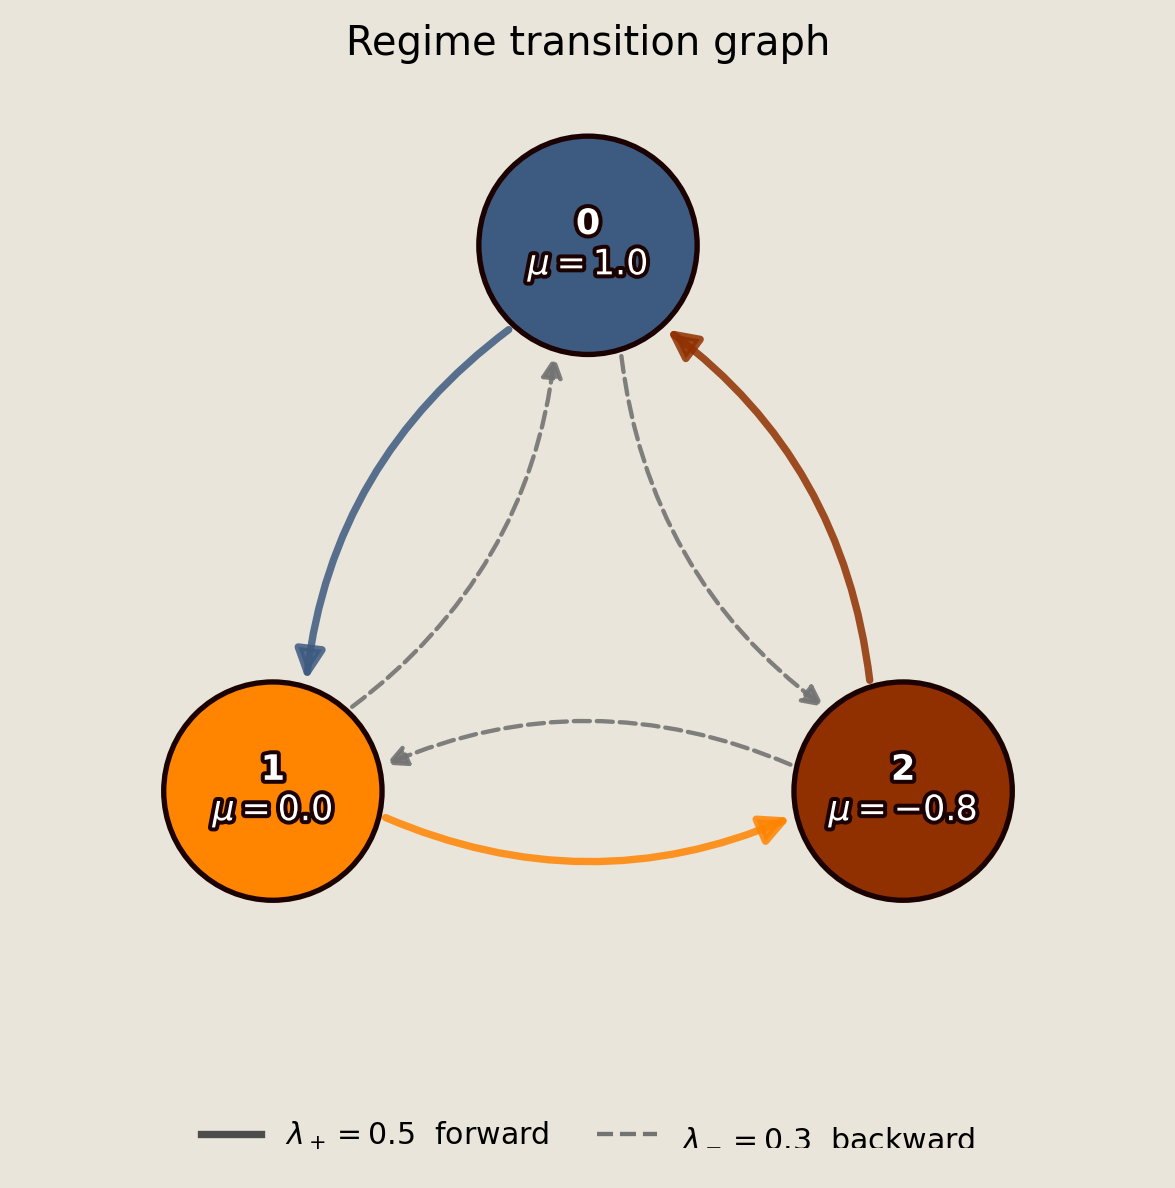

In [11]:
fig_g = P_sch.draw_regime_chain(
    mu=mu,
    lambda_plus=lambda_plus,
    lambda_minus=lambda_minus,
)
savefig(fig_g, "13_regime_transition_graph")

Every displayed transition moves one place around the ring, either forward or backward. When $K=3$, both non-self states are nearest neighbors and either can be reached in one step; on a larger ring, the same gate would still permit only nearest-neighbor moves.

## Building the one-step circuit

With both gates parameterized, we compose them into the single step the sampler will repeat. The Trotter split $T_{\text{Trotter}} = T_{\text{MoG}}\,T_{\text{PditCycle}}$ puts the regime first, so `PditCycle` updates the regime wire, written $|S)$ in the schematic because a wire here carries a probability distribution over states rather than one fixed value. The Gaussian gate then samples the position increment on the wire $|X)$, conditioned on the new regime.

In [12]:
one_step = HybridPCircuit(
    [
        PditCycle(sites=0, dims=K),
        MixtureGaussianGate(sites=(0, 0), dims=(1,), num_components=K),
    ]
)

# Parameters are kept separate from the circuit, one pytree per gate in gate order.
thetas = [cycle_theta, mog_theta]

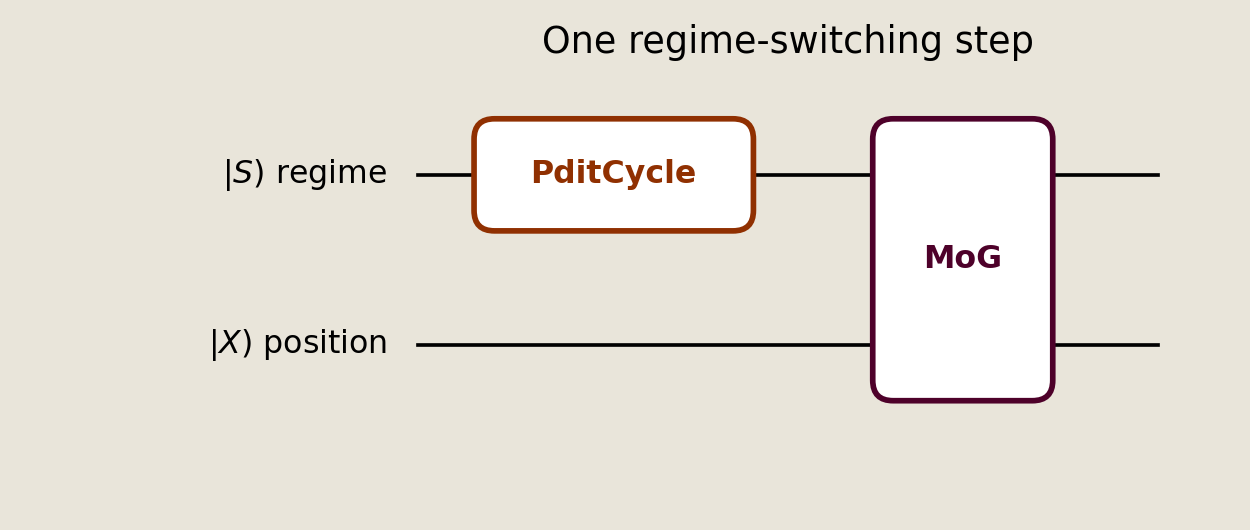

In [13]:
fig_c = P_sch.draw_pcircuit(
    # MoG spans both wires: it reads the regime wire 0 and writes the position wire 1
    [("PditCycle", [0]), ("MoG", [0, 1])],
    wire_labels=[r"$|S)$ regime", r"$|X)$ position"],
    title="One regime-switching step",
)
savefig(fig_c, "13_one_step_circuit")

The schematic shows the ordering that matters: the regime wire $|S)$ is updated before it conditions the Gaussian increment on $|X)$, so each step samples the position under the freshly switched regime.

## Scanning the trajectories

The circuit's `sample` method advances one path by one step, so the time loop and the batching over paths are ours to supply.

In [14]:
def sample_step(key, state):
    return one_step.sample(key, state, thetas)

The `scan` function carries the discrete and continuous state through each circuit step, which is what turns one step into a path of 120 steps of size $\Delta t = T/120$ over the interval $T = 10$. The `vmap` transform then batches the 20,000 trajectory keys into one compiled computation, so every path runs in a single call.

In [15]:
@eqx.filter_jit
def simulate_trajectories(keys):
    def simulate_one(key):
        # Split once so every timestep gets an independent random key.
        step_keys = jax.random.split(key, num_steps)
        init = {
            "discrete": jnp.array([0], dtype=jnp.int32),
            "continuous": jnp.zeros(1),
        }

        def step(state, step_key):
            result = sample_step(step_key, state)
            sampled_discrete = result["discrete"]
            sampled_continuous = result["continuous"]
            new_state = {
                "discrete": sampled_discrete,
                "continuous": sampled_continuous,
            }
            return new_state, (sampled_discrete[0], sampled_continuous[0])

        _, path = jax.lax.scan(step, init, step_keys)
        return path

    return jax.vmap(simulate_one)(keys)


In [16]:
keys = jax.random.split(jax.random.key(SEED), num_trajectories)
regimes, positions = simulate_trajectories(keys)

regimes = np.asarray(regimes)
positions = np.asarray(positions)

# prepend the initial state (t=0, regime 0, position 0) so occupancy and path
# plots start at t=0, before the first PditCycle transition
init_regime = np.zeros((num_trajectories, 1), dtype=regimes.dtype)
init_position = np.zeros((num_trajectories, 1), dtype=positions.dtype)
regimes = np.concatenate([init_regime, regimes], axis=1)
positions = np.concatenate([init_position, positions], axis=1)
time = np.linspace(0.0, T, num_steps + 1)

assert regimes.shape == (num_trajectories, num_steps + 1), regimes.shape
assert positions.shape == (num_trajectories, num_steps + 1), positions.shape
assert set(np.unique(regimes)).issubset(set(range(K))), "invalid regime index"
assert np.all(np.isfinite(positions)), "non-finite positions"

print(
    f"regimes shape: {regimes.shape}   positions shape: {positions.shape}\n"
    f"regime values present: {sorted(np.unique(regimes).tolist())}\n"
    f"position range: [{positions.min():.2f}, {positions.max():.2f}]"
)

regimes shape: (20000, 121)   positions shape: (20000, 121)
regime values present: [0, 1, 2]
position range: [-12.21, 14.83]


## The one-step transition density

Before interpreting a 120-step path, we check one application of the circuit, for which the transition law is known exactly.

Applying `PditCycle` and then `MixtureGaussianGate` produces a Gaussian mixture. Conditional on the updated regime $k$, the increment is $\mathcal{N}(\mu_k\Delta t,\,\sigma_k^2\Delta t)$. Marginalizing over regimes with stationary weights $\pi = (1/3, 1/3, 1/3)$ gives $\Delta x \sim \sum_k \pi_k\,\mathcal{N}(\mu_k\Delta t,\,\sigma_k^2\Delta t)$.

This mixture is the correct pooled target because the sampling scheme preserves those weights. We start equally often from each regime, and the `PditCycle` transition matrix is doubly stochastic: every row and every column sums to 1. A uniform starting distribution therefore remains uniform after one step, so pooling the per-regime samples reproduces the stationary marginal.

The discrete selection is also what changes the family of the marginal law. Composing affine Gaussian gates preserves Gaussianity, whereas selecting among unequal Gaussian components with a discrete regime generally produces a non-Gaussian mixture.

We now sample one-step increments $\Delta x$ from each starting regime and compare the samples with these analytic densities.

In [17]:
N_PER_REGIME = 20_000

In [18]:
def sample_one_step_by_regime(circuit, params, K, seed):
    """Sample one circuit step started from each regime; return new regimes and increments."""
    new_regimes_list, increments_list = [], []
    base_key = jax.random.key(seed)
    for start_regime in range(K):
        # Start equally from each regime; samples are grouped by the new regime
        # S_{n+1} below, so the conditional laws are conditioned on S_{n+1}.
        init_state = {
            "discrete": jnp.array([start_regime], dtype=jnp.int32),
            "continuous": jnp.zeros(1),
        }
        samples_k = circuit.sample_multiple(
            jax.random.fold_in(base_key, start_regime),
            init_state,
            params,
            n_samples=N_PER_REGIME,
        )
        new_regimes_list.append(np.asarray(samples_k["discrete"])[:, 0])
        increments_list.append(np.asarray(samples_k["continuous"])[:, 0])

    all_new_regimes = np.concatenate(new_regimes_list)
    all_increments = np.concatenate(increments_list)
    return all_new_regimes, all_increments


In [19]:
all_new_regimes, all_increments = sample_one_step_by_regime(
    one_step,
    thetas,
    K,
    SEED,
)

print(
    f"{K * N_PER_REGIME} total samples; new-regime counts: "
    f"{[int((all_new_regimes == k).sum()) for k in range(K)]}"
)

60000 total samples; new-regime counts: [20010, 19984, 20006]


In [20]:
conditional_increments = [all_increments[all_new_regimes == k] for k in range(K)]
marginal_increments = all_increments
pi_stat = np.full(K, 1.0 / K)

regime_means = np.asarray(mu * dt)
regime_vars = np.asarray(sigma**2 * dt)

print("regime  mean(Δx)   var(Δx)")
for k in range(K):
    print(f"  {k}     {regime_means[k]:+.4f}    {regime_vars[k]:.4f}")

regime  mean(Δx)   var(Δx)
  0     +0.0833    0.0075
  1     +0.0000    0.0833
  2     -0.0667    0.0208


We evaluate the analytic conditional and mixture densities on a shared grid with the `mixture_density` helper, then overlay them on the sampled histograms so any mismatch is visible without fitting anything.

In [21]:
# A shared grid makes the conditional and marginal curves directly comparable.
x_lo = regime_means.min() - 4.0 * np.sqrt(regime_vars.max())
x_hi = regime_means.max() + 4.0 * np.sqrt(regime_vars.max())
x_grid = np.linspace(x_lo, x_hi, 400)



In [22]:
conditional_pdfs = [
    np.asarray(
        mixture_density(
            mog_theta["means"][k : k + 1],
            mog_theta["log_vars"][k : k + 1],
            jnp.array([1.0]),
            jnp.asarray(x_grid),
        )
    )
    for k in range(K)
]
marginal_pdf = np.asarray(
    mixture_density(
        mog_theta["means"],
        mog_theta["log_vars"],
        jnp.asarray(pi_stat),
        jnp.asarray(x_grid),
    )
)



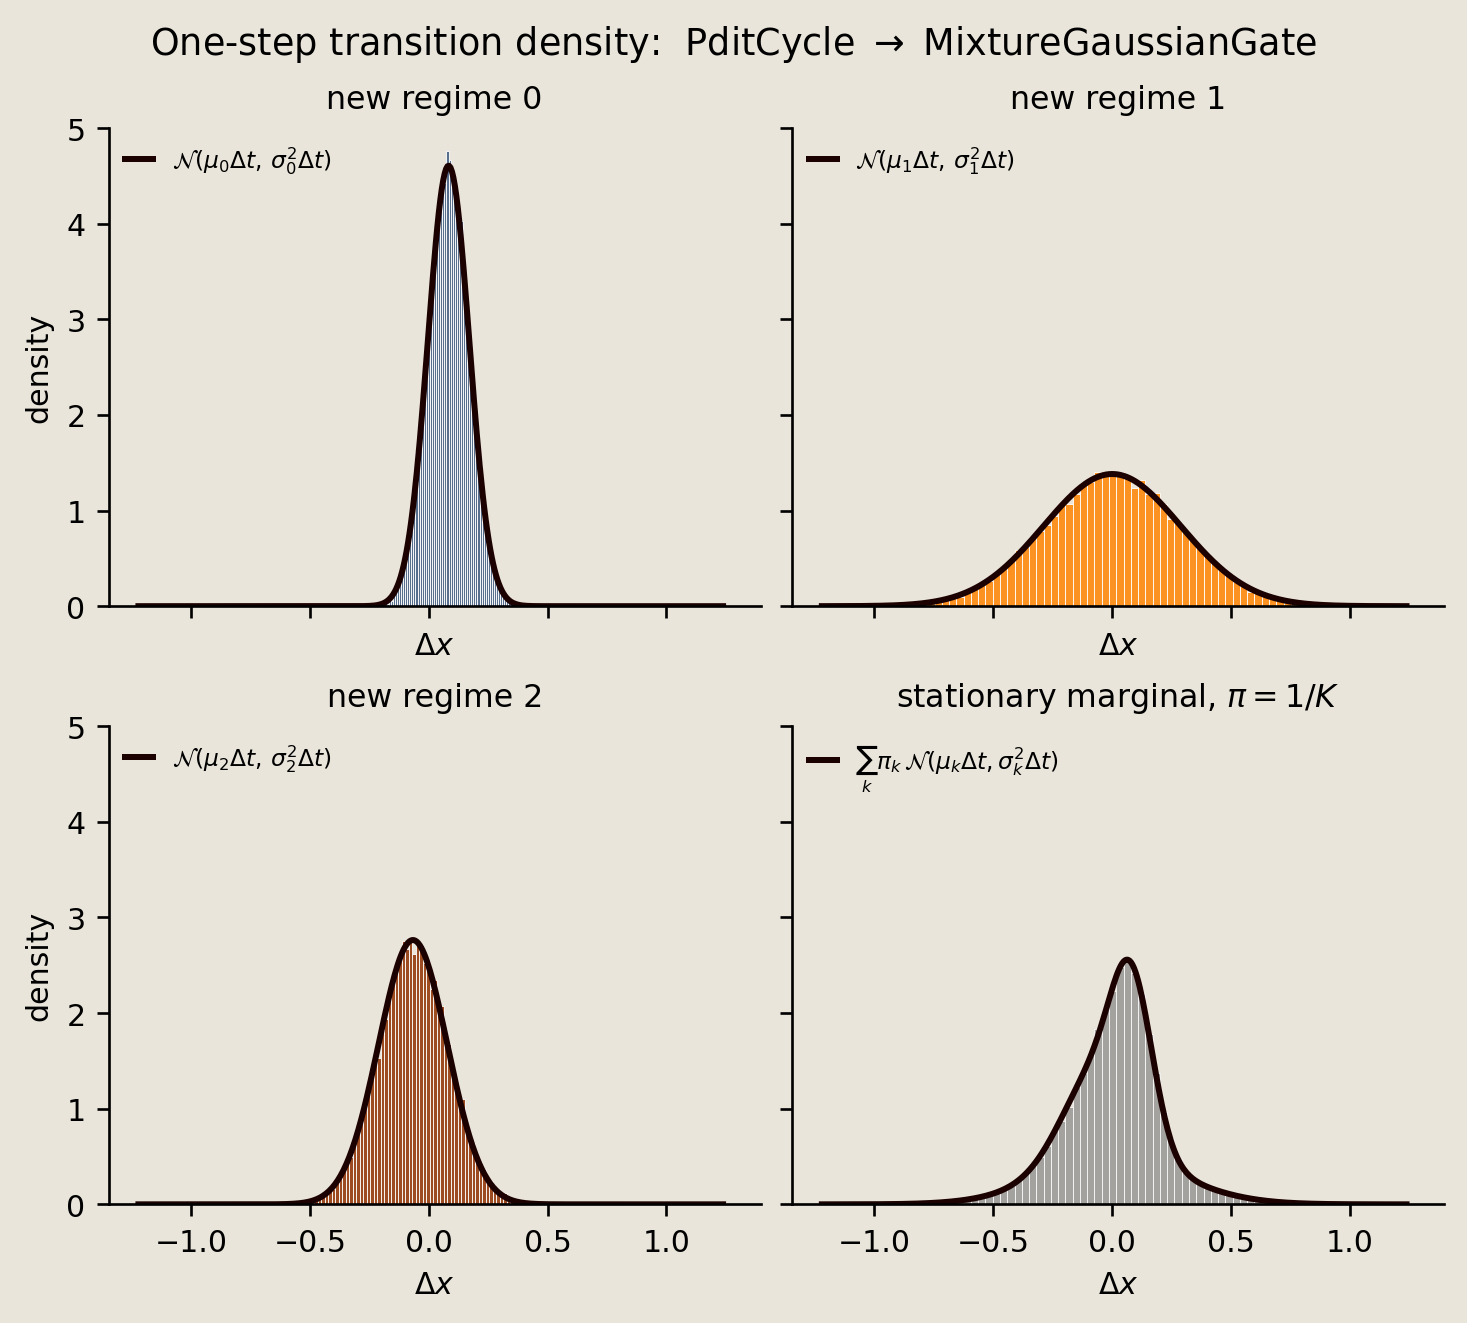

In [23]:
fig = P_fld.plot_transition_density(
    conditional_increments,
    marginal_increments,
    x_grid,
    conditional_pdfs,
    marginal_pdf,
)
savefig(fig, "13_mog_transition_density")

The conditional histograms follow their analytic Gaussian curves: regimes 0 and 2 are narrow, while regime 1 is wider. The stationary marginal blends all three components and is therefore wider than the sharpest conditional law. These overlays reveal the overall agreement, but they do not by themselves quantify discrepancies in the tails.

### Sample-law checks

Curves that overlap by eye can still disagree in the tails, so we put numbers on the comparison against the exact target law.

Each regime-conditional increment is $\mathcal{N}(\mu_k\Delta t,\sigma_k^2\Delta t)$, and the stationary marginal is the mixture $\sum_k \pi_k\,\mathcal{N}(\mu_k\Delta t,\sigma_k^2\Delta t)$.

The Kolmogorov-Smirnov (KS) statistic measures the largest gap between the empirical and true cumulative distribution function (CDF), where 0 is perfect.

We report KS D per regime and for the stationary marginal, which compares the full distributions, and then verify the sample means and variances against the analytic moments, which pins the first two moments down at Monte Carlo tolerance.

In [24]:
def ks_statistic(samples, cdf):
    # KS D straight from the empirical vs theoretical CDF, bypassing scipy's KS
    # wrapper (its _axis_nan_policy path regressed on scipy 1.18); norm.cdf is fine.
    xs = np.sort(np.asarray(samples, dtype=float))
    n = len(xs)
    cdf_vals = np.asarray(cdf(xs), dtype=float)
    d_plus = np.max(np.arange(1, n + 1) / n - cdf_vals)
    d_minus = np.max(cdf_vals - np.arange(0, n) / n)
    return float(max(d_plus, d_minus))




In [25]:
def mixture_cdf(x):
    """Stationary-mixture CDF of the one-step increment."""
    return sum(
        pi_stat[k] * stats.norm.cdf(x, regime_means[k], np.sqrt(regime_vars[k]))
        for k in range(K)
    )




In [26]:
print("target                         KS D")
ks_stats = []
for k in range(K):
    inc = conditional_increments[k]
    loc, scale = regime_means[k], float(np.sqrt(regime_vars[k]))
    D = ks_statistic(inc, lambda x, loc=loc, scale=scale: stats.norm.cdf(x, loc, scale))
    ks_stats.append(D)
    print(f"  Δx | new regime = {k}         {D:.4f}")

D_mix = ks_statistic(marginal_increments, mixture_cdf)
ks_stats.append(D_mix)
print(f"  Δx  (stationary mixture)       {D_mix:.4f}")

min_ks_samples = min([len(inc) for inc in conditional_increments] + [len(marginal_increments)])
ks_tol = 5.0 / np.sqrt(min_ks_samples)
# why: KS sampling error falls as 1/sqrt(n).
if max(ks_stats) >= ks_tol:
    raise AssertionError(
        f"KS D too large: {max(ks_stats):.4f} >= {ks_tol:.4f} "
        "(increments not matching the law)"
    )
print(
    f"\nall KS D < {ks_tol:.4f}; one-step increments match the analytic transition law"
)


target                         KS D
  Δx | new regime = 0         0.0060
  Δx | new regime = 1         0.0051
  Δx | new regime = 2         0.0101
  Δx  (stationary mixture)       0.0036

all KS D < 0.0354; one-step increments match the analytic transition law


In [27]:
for k in range(K):
    inc_k = conditional_increments[k]
    if len(inc_k) <= 100:
        raise AssertionError(f"too few samples for regime {k}")
    mean_atol = 7.0 * np.sqrt(regime_vars[k] / len(inc_k))
    var_rtol = 10.0 * np.sqrt(2.0 / (len(inc_k) - 1))
    np.testing.assert_allclose(inc_k.mean(), regime_means[k], atol=mean_atol)
    np.testing.assert_allclose(inc_k.var(), regime_vars[k], rtol=var_rtol)



In [28]:
mix_mean_exact = float((pi_stat * regime_means).sum())
mix_var_exact = float(
    (pi_stat * (regime_vars + regime_means**2)).sum() - mix_mean_exact**2
)
marginal_mean_atol = 7.0 * np.sqrt(mix_var_exact / len(marginal_increments))
marginal_var_rtol = 10.0 * np.sqrt(2.0 / (len(marginal_increments) - 1))
np.testing.assert_allclose(
    marginal_increments.mean(), mix_mean_exact, atol=marginal_mean_atol
)
np.testing.assert_allclose(marginal_increments.var(), mix_var_exact, rtol=marginal_var_rtol)



In [29]:
print("per-regime Torx moments match analytic to MC tolerance.")
print(
    f"stationary marginal:  Torx mean = {marginal_increments.mean():+.4f}, "
    f"analytic = {mix_mean_exact:+.4f}"
)
print(
    f"stationary marginal:  Torx var  = {marginal_increments.var():.4f}, "
    f"analytic = {mix_var_exact:.4f}"
)


per-regime Torx moments match analytic to MC tolerance.
stationary marginal:  Torx mean = +0.0066, analytic = +0.0056
stationary marginal:  Torx var  = 0.0410, analytic = 0.0410


## Sample paths

With one step matching its law, we can look at what 120 of them produce. Six representative paths are shown separately so crossings don't hide regime switches. Each panel is labeled by path index, and each segment is colored by the active regime. Slate is regime 0 with positive drift, orange is regime 1 with zero drift, and copper is regime 2 with negative drift.

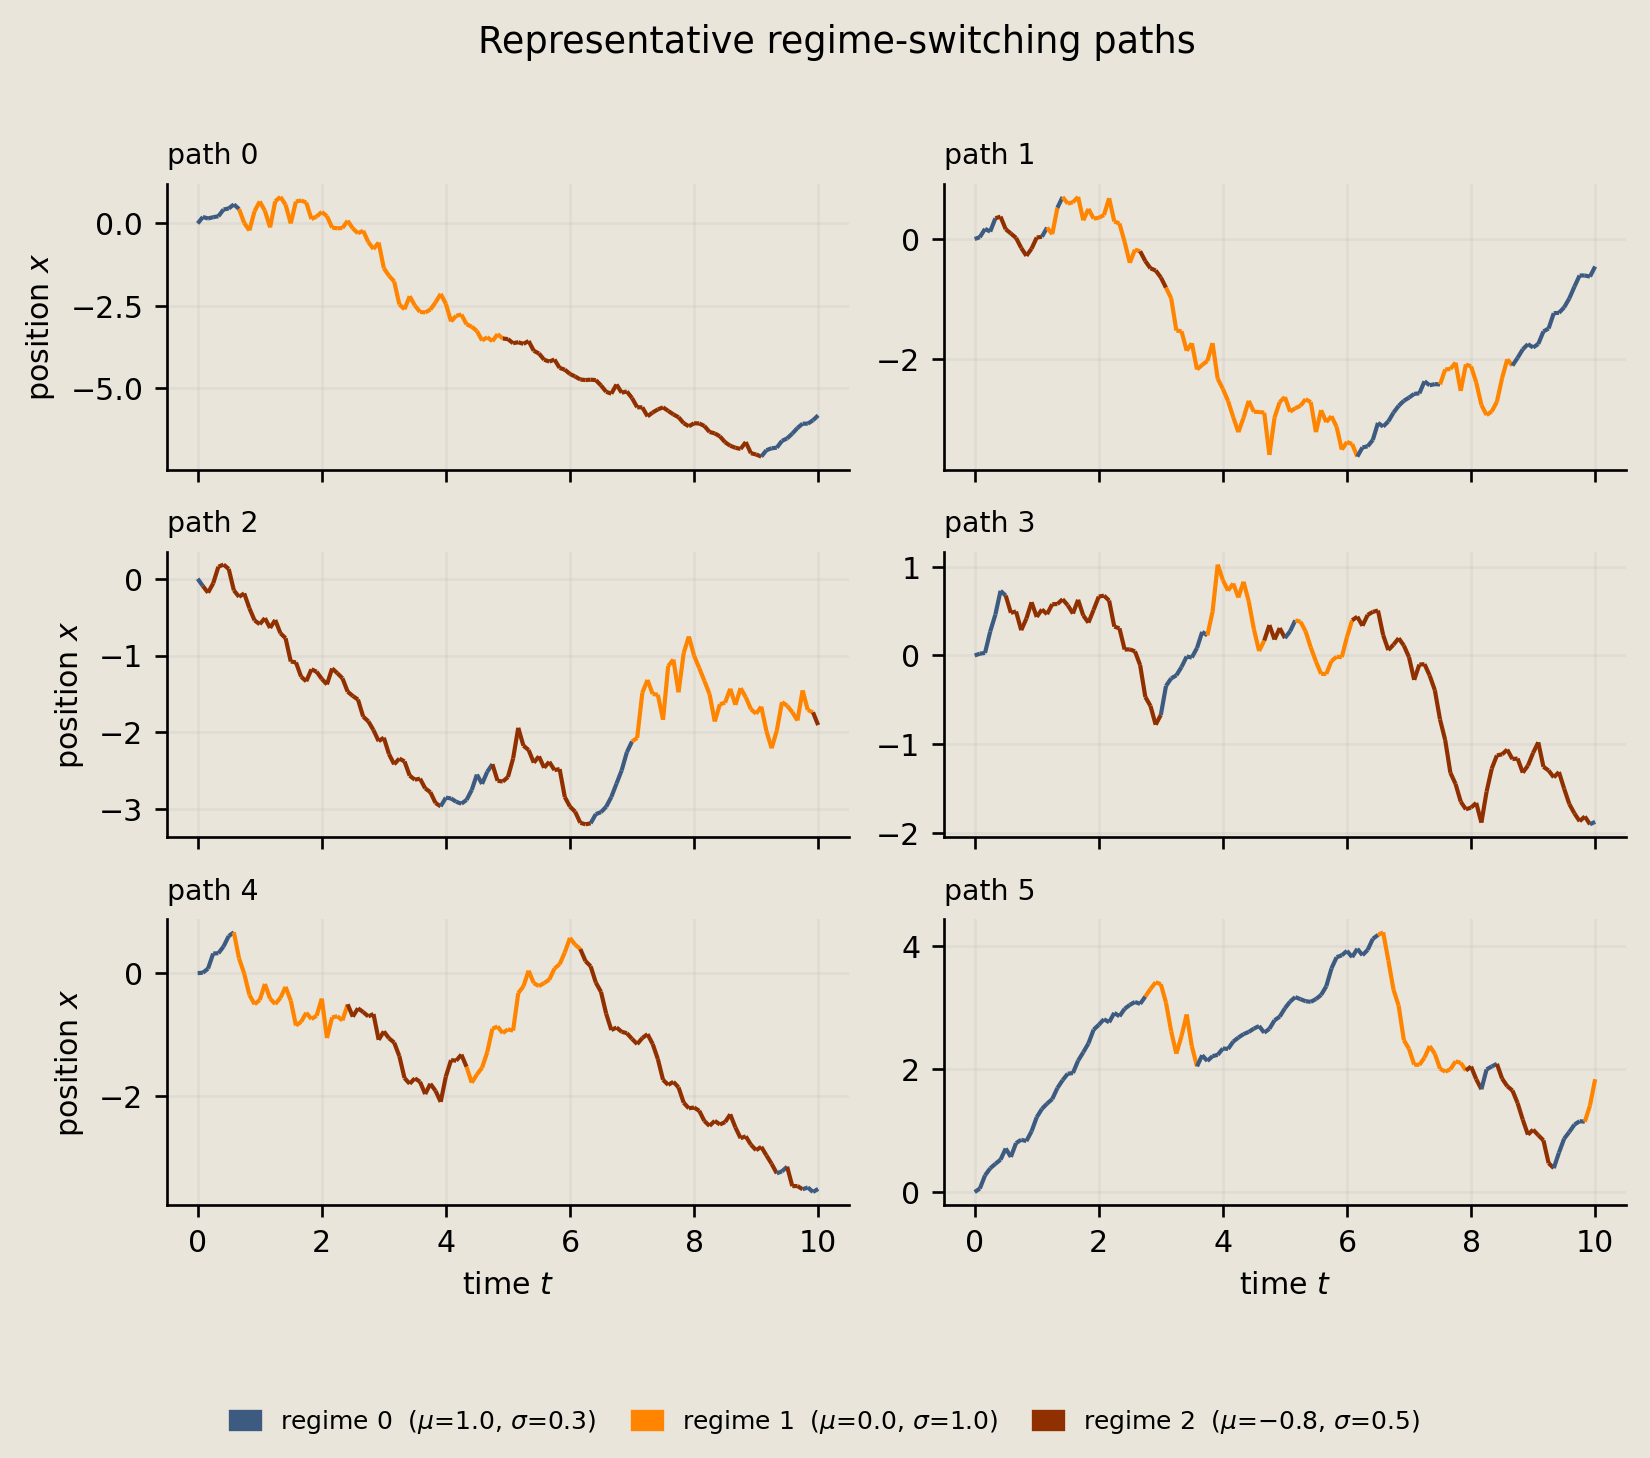

In [30]:
fig = P_fld.plot_sample_paths(time, positions, regimes, mu=mu, sigma=sigma, n_show=6)
savefig(fig, "13_regime_switching_diffusion_trajectories")

The colors track the local behavior of each path: slate regimes set a positive expected direction, copper regimes set a negative expected direction, and orange regimes have the widest typical spread. Gaussian noise can still reverse any realized increment.

## Regime occupancy

Every path starts in regime 0, so the chain has to forget that start before the population can match the uniform stationary law derived above. The occupancy traces let us watch it happen. At each timestep, `occupancy[k]` is the fraction of paths in regime $k$, and separate lines expose every regime against the same $1/3$ stationary reference. The shaded bands show $\pm 2$ Monte Carlo standard errors, the standard error being the spread of the estimate itself across independent paths, which shrinks like $1/\sqrt{N}$ in the number of paths.

In [31]:
occupancy = np.stack([(regimes == k).mean(axis=0) for k in range(K)])

np.testing.assert_allclose(occupancy.sum(axis=0), 1.0, atol=1e-6)
print("regime occupancy sums to 1 at every step")
print(f"time-mean occupancies: {occupancy.mean(axis=1).round(3).tolist()}")

regime occupancy sums to 1 at every step
time-mean occupancies: [0.388, 0.313, 0.299]


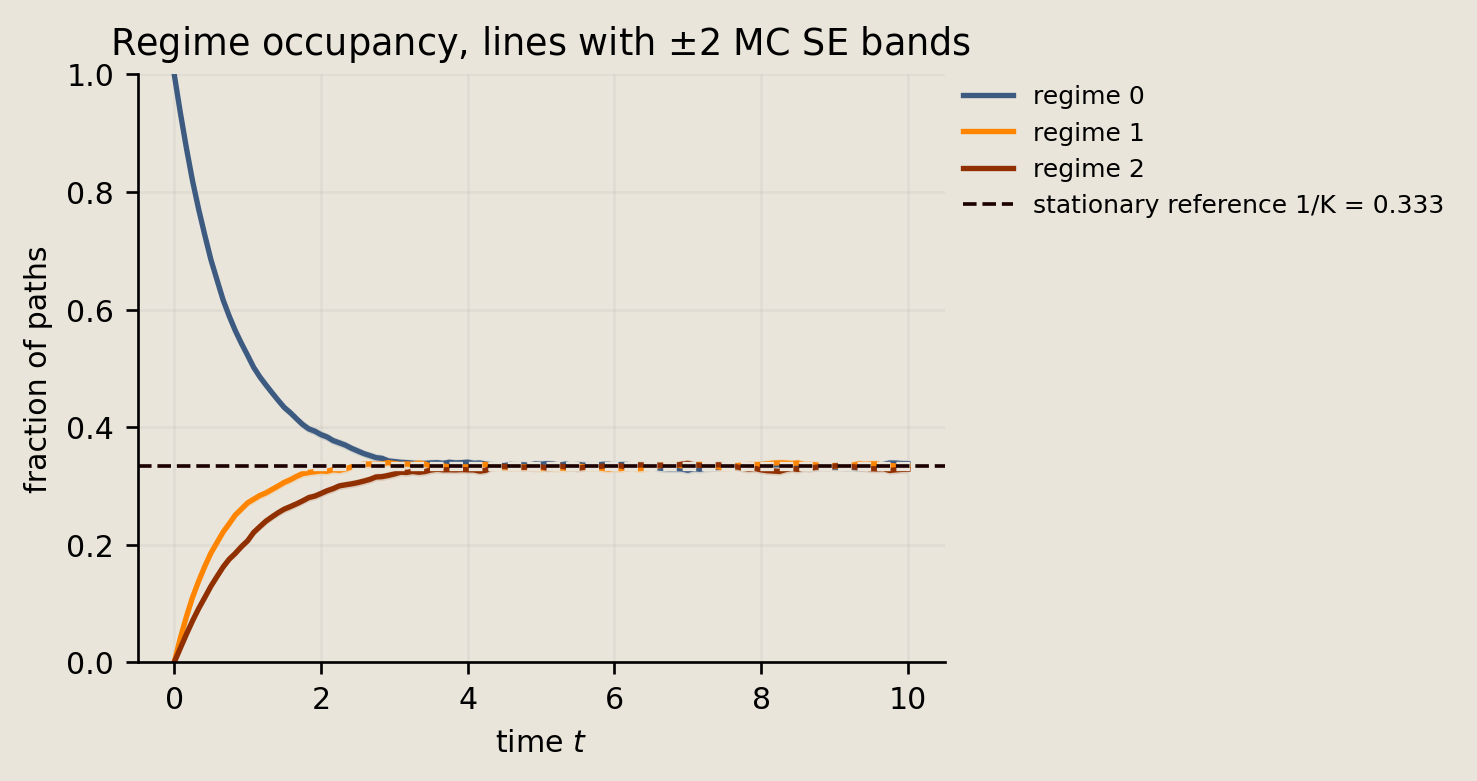

In [32]:
fig = P_fld.plot_regime_occupancy(
    time, occupancy, num_trajectories=num_trajectories
)
savefig(fig, "13_regime_switching_diffusion_regime_histogram")

Regime 0 falls from 1 while regimes 1 and 2 rise, and the three directly comparable lines approach the shared $1/3$ reference as the chain forgets its start.

## Verification

Two properties remain to be checked: whether the regime chain has settled and whether the sampled terminal mean matches the process that the circuit discretizes.

For occupancy, we average the back half of the traces, corresponding to times past $T/2$. Once the chain has mixed, these values should be close to the uniform stationary distribution.

For the terminal mean, we use three references that separate sampling error from timestep error. A transition matrix assembled by hand from the stated one-step probabilities gives the exact mean for the discretized Torx chain and therefore isolates sampling error. Propagating the same construction at half the timestep, and solving the continuous-time Markov chain exactly, show how the discrete reference changes as $\Delta t$ is refined.

In [33]:
uniform_stationary = np.full(K, 1.0 / K)
back_half_occupancy = occupancy[:, num_steps // 2 :].mean(axis=1)
max_dev_back = float(np.max(np.abs(back_half_occupancy - uniform_stationary)))

# why: paths are independent, while back-half time points are correlated.
occupancy_tol = 1.35 / np.sqrt(num_trajectories)

print(
    f"back-half occupancy (mean for t > T/2): {back_half_occupancy.round(4).tolist()}"
)
print(f"uniform stationary  (1/K, 1/K, 1/K):    {uniform_stationary.round(4).tolist()}")
print(f"max |empirical - stationary|:           {max_dev_back:.4f}  (tol {occupancy_tol:.4f})")
if max_dev_back >= occupancy_tol:
    raise AssertionError(
        f"back-half occupancy deviates from uniform stationary by {max_dev_back:.4f} "
        f">= {occupancy_tol:.4f}; chain may not be mixed or sample count too small"
    )


back-half occupancy (mean for t > T/2): [0.3339, 0.3341, 0.332]
uniform stationary  (1/K, 1/K, 1/K):    [0.3333, 0.3333, 0.3333]
max |empirical - stationary|:           0.0014  (tol 0.0095)


A check only convinces if its reference is built without the code under test. So we assemble the stay, forward, and backward matrices by hand from the probabilities stated above, and confirm that `PditCycle` reports the same matrix before that matrix is used for anything.

Propagating the hand-built matrix over the full run gives an exact terminal-mean reference for the discretized Torx chain, which is the number the sampler is held to. Repeating the propagation at half the timestep shows how much of that reference depends on $\Delta t$. A matrix exponential of the continuous-time generator gives the $\Delta t \to 0$ answer, so the two together expose timestep error without reusing Torx's matrix as the reference.

In [34]:
identity = np.eye(K)
forward_shift = np.roll(identity, shift=1, axis=0)
backward_shift = np.roll(identity, shift=-1, axis=0)

# Independent construction from the probabilities stated above.
T_matrix = (
    p_stay * identity
    + p_forward * forward_shift
    + p_backward * backward_shift
)
torx_matrix = np.asarray(PditCycle(sites=0, dims=K).get_matrix(cycle_theta))
np.testing.assert_allclose(torx_matrix, T_matrix, atol=1e-7)

initial_regime_dist = np.array([1.0, 0.0, 0.0])
mu_np = np.asarray(mu)

def discrete_scheme_terminal_mean(step):
    steps = round(T / step)
    stay = 1.0 - (lambda_plus + lambda_minus) * step
    transition = (
        stay * identity
        + lambda_plus * step * forward_shift
        + lambda_minus * step * backward_shift
    )
    regime_dist = initial_regime_dist.copy()
    mean = 0.0
    for _ in range(steps):
        regime_dist = transition @ regime_dist
        mean += float(regime_dist @ mu_np) * step
    return mean

# Continuous-time reference for dp/dt = Qp and dm/dt = mu^T p.
Q = (
    lambda_plus * (forward_shift - identity)
    + lambda_minus * (backward_shift - identity)
)
augmented_generator = np.zeros((K + 1, K + 1))
augmented_generator[:K, :K] = Q
augmented_generator[K, :K] = mu_np
initial_augmented = np.concatenate([initial_regime_dist, [0.0]])
ctmc_terminal_mean = float((expm(T * augmented_generator) @ initial_augmented)[-1])

discrete_terminal_mean = discrete_scheme_terminal_mean(dt)
refined_terminal_mean = discrete_scheme_terminal_mean(dt / 2.0)
empirical_terminal_mean = float(positions[:, -1].mean())
empirical_terminal_sem = float(positions[:, -1].std(ddof=1) / np.sqrt(num_trajectories))

print()
print(
    f"terminal E[x_T], Torx dt scheme: reference = {discrete_terminal_mean:+.4f}, "
    f"empirical = {empirical_terminal_mean:+.4f} "
    f"(SE {empirical_terminal_sem:.3f} from {num_trajectories} paths)"
)
print(
    f"timestep references: dt = {discrete_terminal_mean:+.4f}, "
    f"dt/2 = {refined_terminal_mean:+.4f}, exact CTMC = {ctmc_terminal_mean:+.4f}"
)

# The simulation comparison is against its exact discrete-scheme reference.
terminal_tol = 4.0 * empirical_terminal_sem
if abs(empirical_terminal_mean - discrete_terminal_mean) >= terminal_tol:
    raise AssertionError(
        f"terminal mean off by {empirical_terminal_mean - discrete_terminal_mean:+.4f} "
        f"from the discretized-chain reference (tolerance ±{terminal_tol:.3f})"
    )


terminal E[x_T], Torx dt scheme: reference = +1.4052, empirical = +1.4295 (SE 0.024 from 20000 paths)
timestep references: dt = +1.4052, dt/2 = +1.4441, exact CTMC = +1.4830


The empirical terminal mean is checked only against the exact reference for the discretized Torx chain, because that's the chain the sampler is asked to reproduce. The half-step and matrix-exponential values printed beside it separately show the scale of continuous-time discretization error, so the gap between them is a property of the timestep rather than a defect in the sampler.

In [35]:
print()
print(f"Regime-switching diffusion  (K=3 regimes, 120 steps, {num_trajectories} paths)")
print(f"  position range             : [{positions.min():+.3f}, {positions.max():+.3f}]")
print(f"  terminal mean (empirical)  : {empirical_terminal_mean:+.4f}")
print(f"  terminal mean (Torx dt ref): {discrete_terminal_mean:+.4f}")
print(f"  terminal mean (dt/2 ref)   : {refined_terminal_mean:+.4f}")
print(f"  terminal mean (exact CTMC) : {ctmc_terminal_mean:+.4f}")
print(f"  time-mean occupancy        : {occupancy.mean(axis=1).round(4).tolist()}")
print(f"  back-half occupancy        : {back_half_occupancy.round(4).tolist()}")
print(f"  occupancy vs stationary    : max dev {max_dev_back:.4f}")


Regime-switching diffusion  (K=3 regimes, 120 steps, 20000 paths)
  position range             : [-12.215, +14.826]
  terminal mean (empirical)  : +1.4295
  terminal mean (Torx dt ref): +1.4052
  terminal mean (dt/2 ref)   : +1.4441
  terminal mean (exact CTMC) : +1.4830
  time-mean occupancy        : [0.3881, 0.3132, 0.2987]
  back-half occupancy        : [0.3339, 0.3341, 0.332]
  occupancy vs stationary    : max dev 0.0014


## Conclusion

We constructed a regime-switching diffusion by coupling a cyclic pdit chain to a regime-conditioned Gaussian update. Conditioned on the regime, each continuous step is affine Gaussian; after the discrete state is marginalized out, the same transition is generally a non-Gaussian mixture.

`PditCycle` advances the 3-state chain with first-order transition probabilities, and `MixtureGaussianGate` draws the corresponding position increment. Their order inside `HybridPCircuit` implements a Lie-Trotter Euler step. A jit-compiled `scan` repeats that step 120 times, while `vmap` batches 20,000 independent paths.

The checks distinguish the sampler's law from the error introduced by time discretization. The one-step samples match the conditional and stationary-mixture laws, with the largest KS D at 0.0101 against a sampling tolerance of 0.0354, and the back-half occupancy comes within 0.0014 of the uniform stationary distribution. The sampled terminal mean of $+1.4295$ agrees with the exact discretized-chain reference of $+1.4052$ to about one standard error of 0.024. The independent half-step value $+1.4441$ and exact continuous-time value $+1.4830$ then show the remaining timestep error rather than folding it into the sampling check.

For related constructions, see:
- [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb), affine Gaussian gates and exact moment propagation.
- [`12_langevin_graph_ising.ipynb`](12_langevin_graph_ising.ipynb), a custom nonlinear Langevin gate sampling a soft-spin energy.

## References

1. <span id="ref-yin-zhu-2010"></span>Yin, G.G., Zhu, C. 2010. [*Hybrid Switching Diffusions: Properties and Applications*](https://doi.org/10.1007/978-1-4419-1105-6). Defines switching diffusions and their continuous-time Markov modulation.
2. <span id="ref-kloeden-platen-1992"></span>Kloeden, P.E., Platen, E. 1992. [*Numerical Solution of Stochastic Differential Equations*](https://doi.org/10.1007/978-3-662-12616-5). Gives the Euler-Maruyama discretization used for the Gaussian increment.
3. <span id="ref-trotter-1959"></span>Trotter, H.F. 1959. [*On the product of semi-groups of operators*](https://doi.org/10.1090/S0002-9939-1959-0108732-6). Establishes the sequential operator-product formula behind the split step.